In [1]:
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
import cartopy.crs as ccrs
from heatextremes.metrics import coverage, mean_in_time_batches, probability_of_exceedance_brier_score
import heatextremes as he 
from dask.diagnostics import ProgressBar 
from dask.distributed import Client
from pathlib import Path 
import pandas as pd 

import warnings
from zarr.errors import ZarrUserWarning



In [19]:
ds = xr.open_zarr("/home/kylehall/t2m_verification/t2m_case_metrics.zarr/", chunks={}, consolidated=True)

In [27]:
with ProgressBar():
    toplot = ds['brier_score_35c_t2m_min_6h'].mean('time').compute()

[########################################] | 100% Completed | 30.48 s


/tmp/ipykernel_1850052/3619398296.py:22: FutureWarning: self.axes is deprecated since 2022.11 in order to align with matplotlibs plt.subplots, use self.axs instead.
  for ax in pl.axes.flat:


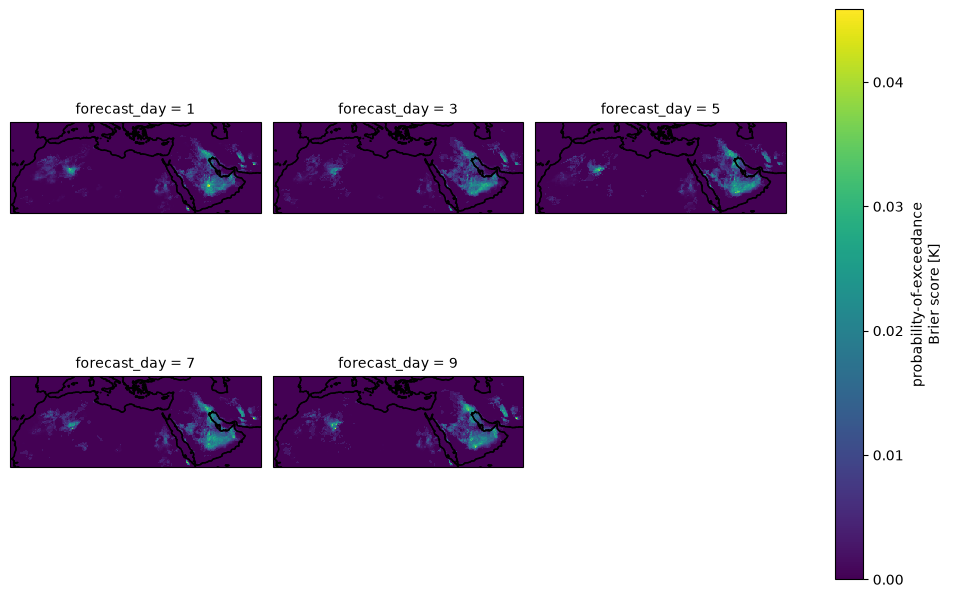

In [32]:

region = toplot.sel(
    latitude=slice(42, 12),
    longitude=slice(-18, 65),
)

pl = region.plot(
    col="forecast_day",
    col_wrap=3,
    subplot_kws={"projection": ccrs.PlateCarree()},
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=0,
)

for ax in pl.axs.flat:
    ax.set_extent(
        [-18, 65, 12, 42],
        crs=ccrs.PlateCarree(),
    )
    ax.coastlines()

for ax in pl.axes.flat:
    ax.coastlines()

In [33]:

era5 = xr.open_dataset('/home/kylehall/t2m_verification/era5_t2m_daily_matched.zarr', chunks={}, consolidated=True)
aifs = xr.open_dataset('/home/kylehall/t2m_verification/aifs_t2m_daily.zarr', chunks={}, consolidated=True)

In [37]:
with ProgressBar():
    rmse = np.sqrt( ((era5 - aifs.mean('number'))**2).mean('time')).compute()

[########################################] | 100% Completed | 101.85 ms
[########################################] | 100% Completed | 107.18 ms
[########################################] | 100% Completed | 102.01 ms
[########################################] | 100% Completed | 102.91 ms
[########################################] | 100% Completed | 17m 49s


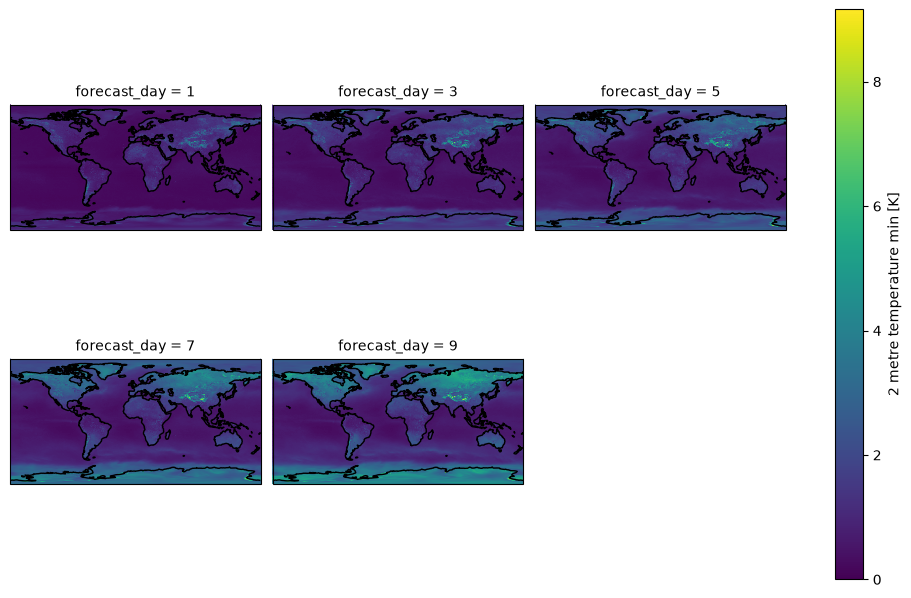

In [40]:

pl = rmse['t2m_min_6h'].plot(
    col="forecast_day",
    col_wrap=3,
    subplot_kws={"projection": ccrs.PlateCarree()},
    transform=ccrs.PlateCarree(),
    cmap="viridis",
    vmin=0,
)

for ax in pl.axs.flat:
    ax.coastlines()
